<font color="red"><h1><b> * MAKE A COPY OF THIS NOTEBOOK SO YOUR EDITS ARE SAVED *</b></h1></font>

# 🤖 **TruthLens Notebook 2: Building Deepfake Detectors**

In NB1, you built intuition: you spotted fakes by eye, explored how GANs and diffusion models generate images, thought about the real-world stakes, and got to know the dataset.

Now it's time to build something. This notebook walks you through training machine learning models to do automatically what you were doing by hand: distinguishing real images from AI-generated ones.

You'll work with real photographs alongside images generated by four AI systems (Stable Diffusion 2.1, SDXL, Stable Diffusion 3, and DALL-E 3). You'll build and compare two core approaches:

| Model | Core Idea | What You'll Learn |
|---|---|---|
| **Custom CNN** | Train a convolutional network from scratch | How CNNs see images; what accuracy actually hides |
| **Transfer Learning** | Fine-tune a network pretrained on ImageNet | How borrowing prior knowledge changes performance |

You'll also run **error analysis** to understand where each model fails, because knowing a model's accuracy is only the beginning. By the end you'll have trained multiple deepfake detectors and have a clear-eyed view of what they can and cannot do.

In [ ]:
#@title **🏗 Setup Cell** {"display-mode":"form", "form-width":"25%"}
#@markdown **Run this first: installs packages, downloads the dataset, and loads libraries.**

import os, gc, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Inspirit utility file
!wget -q "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Modules/inspiritai_util.py"
from inspiritai_util import handle_discussion_response

IMG_SIZE   = 128
batch_size = 32

# Keys are folder names inside {split}/ai/
GENERATOR_NAMES = {
    "sd21":   "SD 2.1",
    "sdxl":   "SDXL",
    "sd3":    "SD 3",
    "dalle3": "DALL-E 3",
}
generators = list(GENERATOR_NAMES.keys())

DATA_ROOT = "/content/genimage_subset"
data_root = Path(DATA_ROOT)

# Download and unzip dataset
if not data_root.exists():
    print("Downloading dataset...")
    !wget -q "https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20TruthLens%3A%20Computer%20Vision%20for%20Deepfake%20Detection/genimage_subset.zip" -O /content/genimage_subset.zip
    !unzip -q /content/genimage_subset.zip -d /content/genimage_subset
    print("Done.")
else:
    print("Dataset already present.")

# Load sample images for M1 filter demo (one per category)
SAMPLE_IMGS = {}
# "val" is the folder name on disk; we use it as our test set
_r_files = list((data_root / "val" / "real" / "real").glob("*.jpg"))
chosen_idx = 1
if _r_files:
    SAMPLE_IMGS["Real"] = np.array(
        Image.open(_r_files[chosen_idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
for _gk, _gname in GENERATOR_NAMES.items():
    _gfiles = list((data_root / "val" / "ai" / _gk).glob("*.jpg"))
    if _gfiles:
        SAMPLE_IMGS[_gname] = np.array(
            Image.open(_gfiles[chosen_idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
print("Setup complete!")

Dataset already present.
Setup complete!


---
---
# **📦 Milestone 1: Preparing the Data**

Before we can train anything, we need to load the images from disk into numpy arrays.
The hidden cell below walks the dataset folders, balances the real/fake split, and
loads and resizes each image.

After running it you'll have four arrays ready to use:
- **`X_train`**, **`y_train`** — training images and labels
- **`X_test`**, **`y_test`**  — test images and labels (held out for evaluation)
- **`test_gen_names`**        — which generator produced each test image (for per-generator accuracy)

In [ ]:
#@title 📦 Data Pipeline {"form-width":"25%","display-mode":"form"}
#@markdown Loads images from the dataset and builds train/test splits. Feel free to try different parameters than your groupmates below to see how results differ!

#@markdown **Note**: loading in more images is recommended but may make later model training slower, especially if you've run into Colab's GPU limits!

import tensorflow as tf
tf.random.set_seed(SEED)

total_images    = 14000  #@param {type:"slider", min:100, max:14000, step:100}
test_percentage = 20   #@param {type:"slider", min:10,  max:40,  step:5}

def _load_img(path):
  return np.array(
    Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)),
    dtype=np.float32
  ) / 255.0

def _collect(split, n_per_class):
  rd = data_root / split / "real" / "real"
  real_ps = list(rd.glob("*.jpg")) if rd.exists() else []
  fake_ps, fake_gs = [], []
  for gen in generators:
    ad = data_root / split / "ai" / gen
    if ad.exists():
      for p in ad.glob("*.jpg"):
        fake_ps.append(p); fake_gs.append(gen)
  ri = random.sample(range(len(real_ps)), min(n_per_class, len(real_ps)))
  fi = random.sample(range(len(fake_ps)), min(n_per_class, len(fake_ps)))
  entries = ([(real_ps[i], 0, "Real") for i in ri] +
             [(fake_ps[i], 1, GENERATOR_NAMES[fake_gs[i]]) for i in fi])
  random.shuffle(entries)
  return [e[0] for e in entries], [e[1] for e in entries], [e[2] for e in entries]

n_per_class_train = int(total_images * (1 - test_percentage / 100)) // 2
n_per_class_test  = int(total_images *      test_percentage / 100)  // 2

print("Building training set...")
tr_paths, tr_labels, _              = _collect("train", n_per_class_train)
X_train = np.stack([_load_img(p) for p in tr_paths])
y_train = np.array(tr_labels, np.int32)

print("Building test set...")
te_paths, te_labels, test_gen_names = _collect("val", n_per_class_test)
X_test  = np.stack([_load_img(p) for p in te_paths])
y_test  = np.array(te_labels, np.int32)

total = len(X_train) + len(X_test)
print("Done!")

Building training set...
Building test set...
Done!


In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Test set
#@markdown *Why do we hold out a separate test set rather than evaluating on the training data? What would happen to our accuracy estimate if we tested on images the model had already seen?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Hardest generator
#@markdown *The dataset has four AI generators (SD 2.1, SDXL, SD 3, DALL-E 3). Which one do you expect will be hardest for the model to detect, and why?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## 1.2. Investigate the Dataset

Before training anything, it is worth spending a few minutes looking at the data itself.
Two common problems in ML datasets are:

- **Class imbalance** — one category has far more examples than the other. A model can score high accuracy just by always predicting the majority class, without learning anything useful.
- **Train / test mismatch** — the two splits look very different, meaning the model trains on one kind of data but is tested on another.

Two helpers are ready to use:

```
check_balance(labels, name)        → reports real vs. fake counts
show_grid(images, labels, ...)     → displays a random sample of images
```

Replace the ALL_CAPS variable names below. Available variables: `X_train`, `y_train`, `X_test`, `y_test`, `test_gen_names`.

In [ ]:
#@title 🔧 Helper code: check_balance, show_grid {"display-mode":"form", "form-width":"25%"}
def check_balance(labels, split_name):
    """Prints real vs. fake count and flags imbalance."""
    n_real = int((labels == 0).sum())
    n_fake = int((labels == 1).sum())
    total  = n_real + n_fake
    status = "balanced ✅" if abs(n_real - n_fake) < 0.1 * total else "imbalanced ⚠️"
    print(f"{split_name:6s}: {n_real:,} real  |  {n_fake:,} fake  →  {status}")

def show_grid(images, labels, gen_names=None, n=8, title="Dataset sample"):
    """Displays a random grid of images labelled real (green) or fake (red)."""
    idxs = random.sample(range(len(images)), min(n, len(images)))
    fig, axes = plt.subplots(1, len(idxs), figsize=(14, 3))
    fig.suptitle(title, fontsize=11)
    for ax, idx in zip(axes, idxs):
        ax.imshow(images[idx])
        if labels[idx] == 0:
            lbl, color = "Real", "green"
        else:
            lbl  = gen_names[idx] if gen_names else "Fake"
            color = "red"
        ax.set_title(lbl, fontsize=8, color=color)
        ax.axis("off")
    plt.tight_layout(); plt.show()


Train : 5,600 real  |  5,600 fake  →  balanced ✅
Test  : 1,400 real  |  1,400 fake  →  balanced ✅


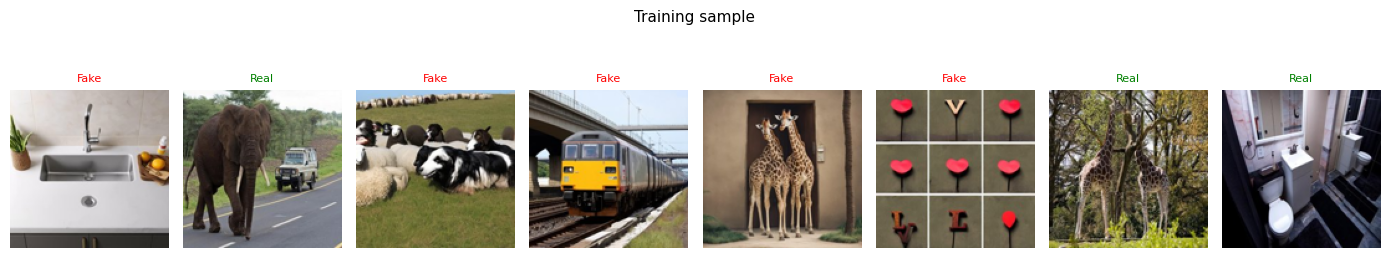

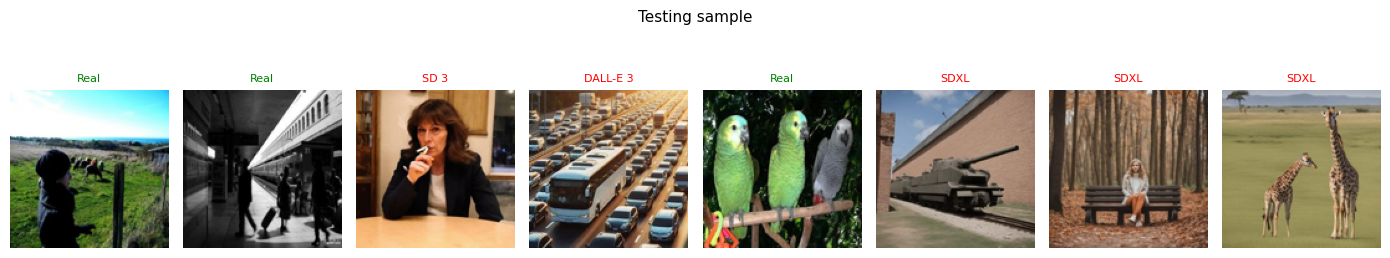

In [ ]:
# ── Task 1: Are both splits balanced? ─────────────────────────────────────────
check_balance(y_train, "Train")
check_balance(y_test,   "Test")

# ── Task 2: What do the training images look like? ────────────────────────────
show_grid(X_train, y_train, title="Training sample")

# ── Task 3: Does the test set look similar? ─────────────────────────────
# test_gen_names tells show_grid which generator produced each fake image.
show_grid(X_test, y_test, gen_names=test_gen_names, title="Testing sample")


---
---
# **🧠 Milestone 2: How Do Machines See?**

Before we train a detector, we need to understand how the detector *sees* images.
Neural networks don't look at pictures the way we do — they process images as grids of numbers
and build up their understanding one mathematical operation at a time.

The key building block is called a **filter** (or kernel). Let's see one in action.

## 2.1. What Does a Filter Do?

A filter is a tiny grid of numbers (usually 3×3) that slides across an image.
At every position it multiplies its values by the underlying pixels, adds them up, and writes one number to the output.
Different number patterns detect different things — edges, textures, blurriness.

Try the interactive demo to see the sliding window and its effect on different parts of an image:

👉 **[Image Kernels — setosa.io](https://setosa.io/ev/image-kernels/)**

Then run the cell below to apply the same filters to images from our actual dataset.

In [ ]:
#@title 🔬 Filter demo {"display-mode":"form", "form-width":"25%", "run":"auto"}
from scipy.signal import convolve2d

image_choice  = "SD 3"  #@param ["Real", "SD 2.1", "SDXL", "SD 3", "DALL-E 3"]
filter_choice = "Sobel (horizontal edges)"  #@param ["Sobel (horizontal edges)", "Sobel (vertical edges)", "Sharpen", "Blur"]

FILTERS = {
    "Sobel (horizontal edges)": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float),
    "Sobel (vertical edges)":   np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float),
    "Sharpen":                  np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float),
    "Blur":                     np.ones((3,3)) / 9.0,
}

img_uint8 = SAMPLE_IMGS.get(image_choice, list(SAMPLE_IMGS.values())[0])
img_arr   = img_uint8.mean(axis=2).astype(np.float32) / 255.0
kernel    = FILTERS[filter_choice]
filtered  = convolve2d(img_arr, kernel, mode="same")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"Filter: {filter_choice}  |  Image: {image_choice}", fontsize=12)
axes[0].imshow(img_uint8); axes[0].set_title("Original"); axes[0].axis("off")

vmax = np.abs(kernel).max() or 1
im = axes[1].imshow(kernel, cmap="RdBu", vmin=-vmax, vmax=vmax)
axes[1].set_title("Filter kernel")
for i in range(kernel.shape[0]):
    for j in range(kernel.shape[1]):
        val = kernel[i, j]
        lbl = f"{int(val)}" if val == int(val) else f"{val:.2f}"
        axes[1].text(j, i, lbl, ha="center", va="center", fontsize=13,
                     color="white" if abs(val) > 0.4*vmax else "black")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_xticks([]); axes[1].set_yticks([])

axes[2].imshow(np.abs(filtered), cmap="gray")
axes[2].set_title("After convolution"); axes[2].axis("off")
plt.tight_layout(); plt.show()


In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Which filter would a deepfake detector care about?
#@markdown *Try the Sobel filters (edge detectors), Sharpen, and Blur on both real and AI images. Blur averages neighbouring pixels; Sharpen amplifies local contrast; Sobel highlights edges. Which type of filter do you think would be most useful inside a deepfake-detecting CNN, and why? What kind of image feature might reveal that an image was AI-generated?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## 2.2. From One Filter to a Full Network

A single filter can detect edges or textures. A CNN stacks many learned filters across many layers,
each building on the previous one — going from simple to complex:

| Layer | What it typically learns |
|---|---|
| First conv. layer | Edges, colour gradients |
| Middle layers | Textures, repeated patterns, object parts |
| Later layers | High-level features: faces, backgrounds, artifacts |

The network learns all the filters automatically from the training data — we don't design them by hand.

To see this in action, try drawing a digit in this interactive visualizer and watch the signal flow through each layer:

👉 **[CNN Visualizer — adamharley.com](https://adamharley.com/nn_vis/cnn/2d.html)**

Each square in the middle panels is one filter's response. Notice how early layers respond to edges
and later layers respond to larger, more recognizable shapes.

## 2.3. The Architecture We'll Build

Here's the exact network we'll train in Milestone 3:

```
Input image  (128 × 128 pixels, 3 colour channels)
    ↓
Conv layer 1  — 32 filters, 3×3   → finds edges and colour patches
MaxPooling    — shrinks 128→64    → keeps only the strongest responses
    ↓
Conv layer 2  — 64 filters, 3×3   → combines edges into textures
MaxPooling    — shrinks 64→32
    ↓
Conv layer 3  — 128 filters, 3×3  → detects higher-level patterns and artifacts
MaxPooling    — shrinks 32→16
    ↓
GlobalAveragePooling → collapses each filter's 16×16 output to one number
    ↓
Dense layer   — 128 neurons        → learns which combinations matter
    ↓
Output        — 1 neuron (sigmoid) → outputs a number from 0 to 1
                                     above 0.5 = "probably fake"
```

Each convolutional layer scans the image with small filters, looking for patterns. But we don't want the network to be too fussy about *where* a suspicious pattern appears. A blurry eye is a blurry eye whether it sits two pixels left or right. **MaxPooling** handles this by keeping only the strongest signal from each small region, which also shrinks the data so later layers have less to process.

After three rounds of conv + pool, each of the 128 filters has produced a 16×16 response map (a small grid showing how strongly that filter responded across the image). **GlobalAveragePooling** collapses each of those maps into a single number, giving us a compact 128-number summary of everything the network noticed.

Those 128 numbers flow into a Dense layer that learns which combinations are suspicious, and finally into a single output neuron. The **sigmoid** function squashes its output to a value between 0 and 1, which we treat as a probability: above 0.5 means the network thinks the image is fake.

---
---
# **🔨 Milestone 3: Your First Deepfake Detector**

## 3.1. Design the Model

Here we introduce **Keras**, a Python library for building neural networks. Instead of writing the math yourself, you stack layers like building blocks and Keras handles the rest. We use `Sequential` to define a network where data flows straight through from top to bottom.

Your task is to complete the CNN skeleton below based on the outline above. Block 1 is already written for you. Add the missing layers in Blocks 2 and 3, then compile the model.

Each block follows the same pattern:
- A `Conv2D` layer that learns filters to detect patterns
- A `MaxPooling2D` layer that shrinks the image and keeps strong signals

**Tips:**
- `Conv2D(64, (3, 3), activation="relu", padding="same")`: 64 filters, size 3x3
- `MaxPooling2D()`: no arguments needed, defaults to a 2x2 window
- `Dense(128, activation="relu")`: a fully connected layer with 128 neurons
- Note the commas at the end of every layer! This is because this cell is actually a long list of layers, and those commas are telling Python where each layer's code ends.

In [ ]:
# Import model pieces from the Keras library
import keras
from keras import Sequential
from keras.layers import (
  Input, Conv2D, MaxPooling2D,
  GlobalAveragePooling2D, Dense, Dropout
)

# Start building the model!
model = Sequential([
  Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

  # Block 1: Detect simple edges and colors (already done for you)
  Conv2D(32, (3, 3), activation="relu", padding="same"),
  MaxPooling2D(),


  ### ✍️ YOUR CODE HERE
  # Block 2: Detect textures and combinations
  # Add a Conv2D with 64 filters (same style as Block 1)
  Conv2D(64, (3, 3), activation="relu", padding="same"),
  MaxPooling2D(),
  # Add a MaxPooling2D layer


  # Block 3: Detect higher-level features and artifacts
  # Add a Conv2D with 128 filters
  Conv2D(128, (3, 3), activation="relu", padding="same"),
  MaxPooling2D(),
  # Add a MaxPooling2D layer

  ### ✍️ END CODE HERE



  # Collapse 2D feature maps into a single vector per image
  GlobalAveragePooling2D(),



  ### ✍️ YOUR CODE HERE
  # Add a Dense layer with 128 units and "relu" activation
  Dense(128, activation="relu"),


  ### ✍️ END CODE HERE



  # Dropout turns off random neurons during training to prevent memorizing
  Dropout(0.5),

  # Output: probability that the image is fake (0 = real, 1 = fake)
  Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3.2. Compile and Train Your Model

Now that the architecture is built, you need to compile it (tell Keras which optimizer and loss to use)
and then train it (run the data through repeatedly, adjusting weights each pass).

The exercise below walks you through both steps.

In [ ]:
# Exercise 3.2: Compile and Train Your Model
#
# Replace each ALL_CAPS placeholder with the right value, then run.
#
#   LEARNING_RATE  — how big each weight update is. Try 0.001.
#   MAX_EPOCHS     — maximum training passes. Try 20.
#   PATIENCE       — epochs with no improvement before stopping. Try 3.
#
#   TRAIN_IMAGES / TRAIN_LABELS — the training data
#   TEST_IMAGES  / TEST_LABELS  — the testing data

# ── Settings ───────────────────────────────────────────────────────────────
learning_rate = 0.001  # try 0.001
max_epochs    = 20     # try 20
patience      = 3       # try 3

# ── Compile ────────────────────────────────────────────────────────────────
# binary_crossentropy: penalizes probability guesses more the further they are
# from the true label. Standard choice for any two-class problem.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ── Train ──────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=batch_size,
    shuffle=True,
    epochs=max_epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True
        )
    ]
)


Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5714 - loss: 0.6689 - val_accuracy: 0.6171 - val_loss: 0.6477
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6584 - loss: 0.6216 - val_accuracy: 0.6696 - val_loss: 0.5993
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6818 - loss: 0.5960 - val_accuracy: 0.7279 - val_loss: 0.5462
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6974 - loss: 0.5772 - val_accuracy: 0.7379 - val_loss: 0.5291
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7168 - loss: 0.5521 - val_accuracy: 0.7575 - val_loss: 0.5115
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7369 - loss: 0.5292 - val_accuracy: 0.7671 - val_loss: 0.4927
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7494 - loss: 0.5075 - val_accuracy: 0.7736 - val_loss: 0.4859
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7611 - loss: 0.4921 - val_acc

## Analyzing Model Performance Through Training Curves

Each time the model sees the full training set once, that is called an **epoch**.
After every epoch, we record two numbers:

| Curve | What it measures |
|---|---|
| **Training accuracy** | Correct predictions on images the model was **trained** on |
| **Validation accuracy** | Correct predictions on images the model has **never** seen |

The gap between these curves tells you what's happening:

```
Training ≈ Validation (both high)    →  good fit ✅
Training >> Validation               →  overfitting ⚠️  (model memorized training data)
Training ≈ Validation (both low)     →  underfitting ⚠️  (model hasn't learned enough)
```

**EarlyStopping** monitors validation loss and stops training when it stops improving,
then restores the weights from the best epoch. This prevents wasting time on epochs
that make overfitting worse.

Run the next two cells to see how your model did!

In [ ]:
#@title 🔧 Helper code: plot_history {"display-mode":"form", "form-width":"25%"}
def plot_history(history, title="Training Curves"):
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))
  axes[0].plot(history.history["accuracy"],     label="train")
  axes[0].plot(history.history["val_accuracy"], label="test")
  axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Accuracy"); axes[0].legend()
  axes[1].plot(history.history["loss"],         label="train")
  axes[1].plot(history.history["val_loss"],     label="test")
  axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Loss"); axes[1].legend()
  plt.suptitle(title, fontsize=13)
  plt.tight_layout(); plt.show()


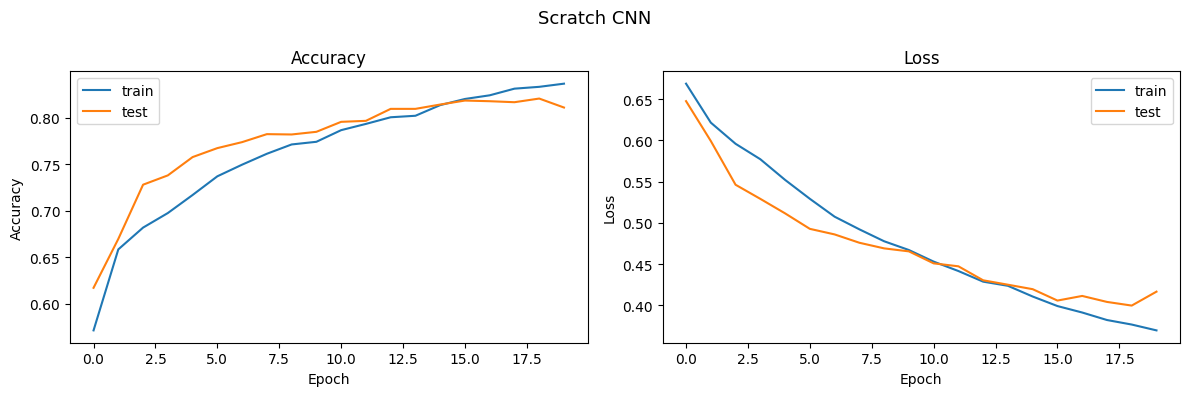

In [ ]:
plot_history(history, "Scratch CNN")

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Reading the training curves
#@markdown *What pattern do you see in the accuracy and loss curves? Is training accuracy higher than validation accuracy? If so, what does that tell you about how well the model generalizes?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Early stopping
#@markdown *At what epoch did early stopping kick in? Why is it useful to stop automatically rather than always running the full number of epochs?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

---
---
# **🔍 Milestone 4: Error Analysis**

Your model has an accuracy number. But accuracy is just an average. It tells you what fraction of images the model got right, without telling you *which* images, *why* it was wrong, or *how wrong* it was.

Error analysis is the habit of looking past the headline number. We will work through three questions in order:

1. **What errors are we making, and how many?** Count false positives and false negatives; see which generators are hardest.
2. **What do these errors look like?** Inspect the actual misclassified images for common patterns.
3. **Why are these errors happening?** Use saliency maps to see which pixels drove the wrong prediction.

## 4.1. Run Predictions

First, let's run the model on the test set and collect all predictions.

In [ ]:
#@title 🔮 Prediction and analysis helpers {"display-mode":"form"}
import pandas as pd
import seaborn as sns

def get_predictions(model, batch_size=32):
  # Run model on the held-out test set and return a results DataFrame.
  preds = model.predict(X_test, batch_size=batch_size, verbose=0).flatten()
  return pd.DataFrame({
    'img_idx':    np.arange(len(X_test)),
    'true_label': y_test,
    'pred_label': (preds > 0.5).astype(int),
    'confidence': preds,
    'generator':  test_gen_names,
  })

def get_saliency_map(model, img_array):
  import tensorflow as tf
  img_tensor = tf.cast(img_array, tf.float32)
  with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    pred = model(tf.expand_dims(img_tensor, 0))
  grads    = tape.gradient(pred, img_tensor)
  saliency = tf.reduce_max(tf.abs(grads), axis=-1).numpy()
  saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
  return saliency

def show_misclassified(results_df, model_name="Model", n=6):
  wrong = results_df[results_df['true_label'] != results_df['pred_label']].sample(min(n, len(results_df)))
  fig, axes = plt.subplots(2, n//2, figsize=(14, 6))
  fig.suptitle(f"Misclassified Examples ({model_name})", fontsize=13)
  for ax, (_, row) in zip(axes.flatten(), wrong.iterrows()):
    ax.imshow(X_test[row['img_idx']]); ax.axis("off")
    true = "Real" if row['true_label'] == 0 else "Fake"
    pred = "Real" if row['pred_label'] == 0 else "Fake"
    conf_pct = (1 - row['confidence']) * 100 if row['pred_label'] == 0 else row['confidence'] * 100
    ax.set_title(
      f"true: {true}\npred: {pred} ({conf_pct:.0f}% conf)\n({row['generator']})",
      fontsize=7
    )
  plt.tight_layout(); plt.show()


def show_saliency(model, results_df, model_name="Model", n=4):
  samples = results_df.sample(min(n, len(results_df)))
  fig, axes = plt.subplots(n, 2, figsize=(6, n*3))
  fig.suptitle(f"Saliency Maps: What Is the Model Focusing On? ({model_name})", fontsize=11)
  for i, (_, row) in enumerate(samples.iterrows()):
    img_array = X_test[row['img_idx']]
    saliency  = get_saliency_map(model, img_array)
    true = "Real" if row['true_label'] == 0 else "Fake"
    pred = "Real" if row['pred_label'] == 0 else "Fake"
    conf_pct = (1 - row['confidence']) * 100 if row['pred_label'] == 0 else row['confidence'] * 100
    axes[i, 0].imshow(img_array); axes[i, 0].axis("off")
    axes[i, 0].set_title(f"true: {true} | pred: {pred} ({conf_pct:.0f}% conf)", fontsize=8)
    axes[i, 1].imshow(saliency, cmap="hot"); axes[i, 1].axis("off")
    axes[i, 1].set_title("Saliency", fontsize=8)
  plt.tight_layout(); plt.show()

results_df  = get_predictions(model)
overall_acc = (results_df['true_label'] == results_df['pred_label']).mean()
print(f"Scratch CNN validation accuracy: {overall_acc:.3f}")

Scratch CNN validation accuracy: 0.820


## 4.2. What Errors Are We Making, and How Many?

Before looking at individual images, let's count the errors at the population level:

- **Accuracy by generator:** which sources does the model struggle with most?
- **Confusion matrix:** how many false positives (real content flagged as fake) vs. false negatives (fake content missed)?

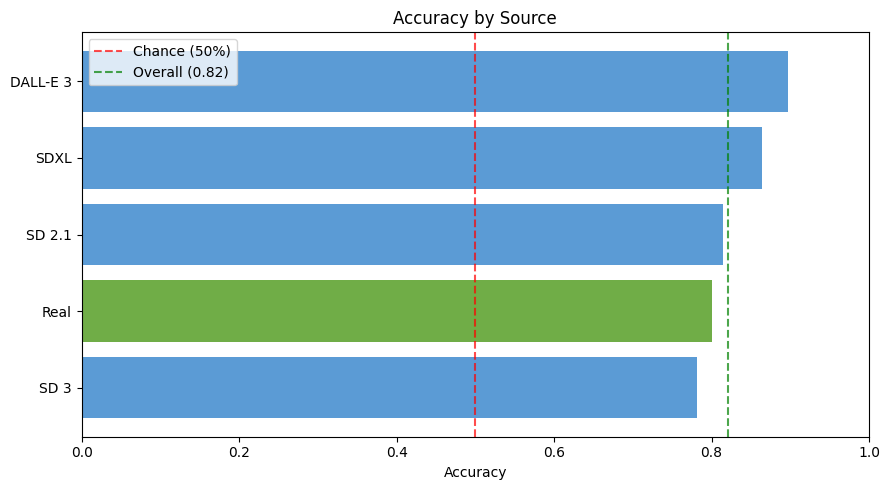

Green bar = real images correctly left alone
Blue/red bars = fake images correctly flagged, by generator


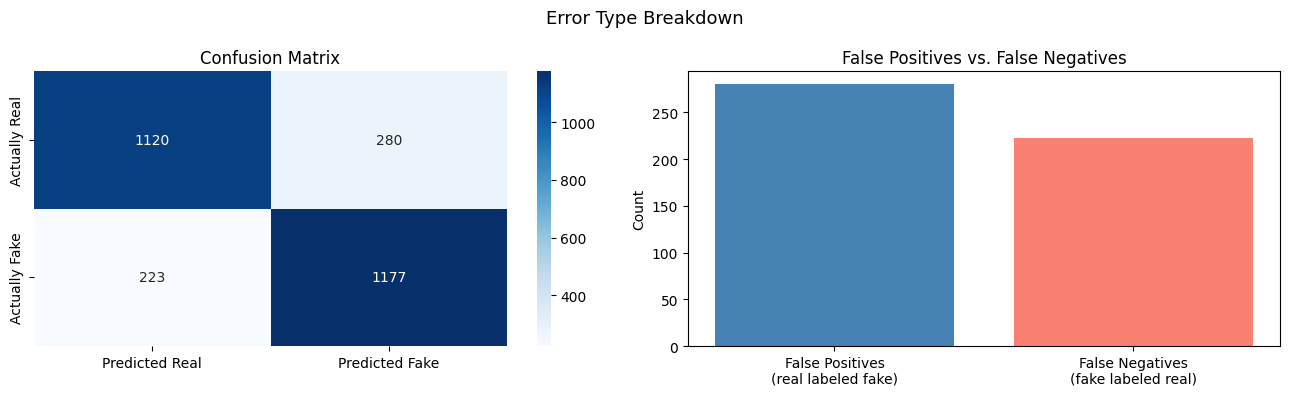

False Positives (real labeled fake): 280  <- risk of over-censorship
False Negatives (fake labeled real): 223  <- risk of misinformation passing through


In [ ]:
#@title 📊 Breakdown & Error Analysis {"display-mode":"form"}
import seaborn as sns

# 1. Accuracy by source (Real + each fake generator)
gen_acc = results_df.groupby('generator').apply(
  lambda x: (x['true_label'] == x['pred_label']).mean(), include_groups=False
).reset_index()
gen_acc.columns = ['generator', 'accuracy']
gen_acc = gen_acc.sort_values('accuracy')

colors = ['#70AD47' if g == 'Real' else
          ('salmon' if a < 0.6 else '#5B9BD5')
          for g, a in zip(gen_acc['generator'], gen_acc['accuracy'])]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(gen_acc['generator'], gen_acc['accuracy'], color=colors)
ax.axvline(0.5,         color='red',   linestyle='--', alpha=0.7, label='Chance (50%)')
ax.axvline(overall_acc, color='green', linestyle='--', alpha=0.7,
           label=f'Overall ({overall_acc:.2f})')
ax.set_title('Accuracy by Source')
ax.set_xlabel('Accuracy')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()
print("Green bar = real images correctly left alone")
print("Blue/red bars = fake images correctly flagged, by generator")

# 2. Confusion matrix and FP/FN breakdown
fp = len(results_df[(results_df['true_label'] == 0) & (results_df['pred_label'] == 1)])
fn = len(results_df[(results_df['true_label'] == 1) & (results_df['pred_label'] == 0)])
tp = len(results_df[(results_df['true_label'] == 1) & (results_df['pred_label'] == 1)])
tn = len(results_df[(results_df['true_label'] == 0) & (results_df['pred_label'] == 0)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
  xticklabels=['Predicted Real', 'Predicted Fake'],
  yticklabels=['Actually Real',  'Actually Fake'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

axes[1].bar(['False Positives\n(real labeled fake)', 'False Negatives\n(fake labeled real)'],
            [fp, fn], color=['steelblue', 'salmon'])
axes[1].set_title('False Positives vs. False Negatives')
axes[1].set_ylabel('Count')
plt.suptitle("Error Type Breakdown", fontsize=13)
plt.tight_layout()
plt.show()

print(f"False Positives (real labeled fake): {fp}  <- risk of over-censorship")
print(f"False Negatives (fake labeled real): {fn}  <- risk of misinformation passing through")

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Which generator was hardest?
#@markdown *Which AI generator was the model worst at detecting? Were you surprised? How does this connect to what you know about when each generator was released?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ False positives vs. false negatives
#@markdown *Look at the false positive vs. false negative counts. In a real content-moderation system, which type of error is more harmful — flagging real content as fake, or letting fake content through? Does your answer change depending on the application?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## 4.3. What Do These Errors Look Like?

Now let's look at the actual images the model got wrong. Looking at misclassified examples directly often reveals patterns that no metric can capture — maybe the model struggles with one type of scene, lighting condition, or artistic style.

In [ ]:
#@title 🔧 Helper code: show_error_type {"display-mode":"form", "form-width":"25%"}
def show_error_type(df, title, n=4):
    sample = df.sample(min(n, len(df)), random_state=42)
    if len(sample) == 0:
        print(f"{title}: none found."); return
    fig, axes = plt.subplots(1, len(sample), figsize=(3*len(sample)+1, 3))
    if len(sample) == 1: axes = [axes]
    fig.suptitle(title, fontsize=10)
    for ax, (_, row) in zip(axes, sample.iterrows()):
        ax.imshow(X_test[row["img_idx"]]); ax.axis("off")
        pred = "Real" if row["pred_label"] == 0 else "Fake"
        conf_pct = (1 - row["confidence"]) * 100 if row["pred_label"] == 0 else row["confidence"] * 100
        ax.set_title(f"pred: {pred} ({conf_pct:.0f}% conf)\n({row['generator']})",
                     fontsize=7)
    plt.tight_layout(); plt.show()

False positives (real images flagged as fake): 280
False negatives (fakes that slipped through) : 223


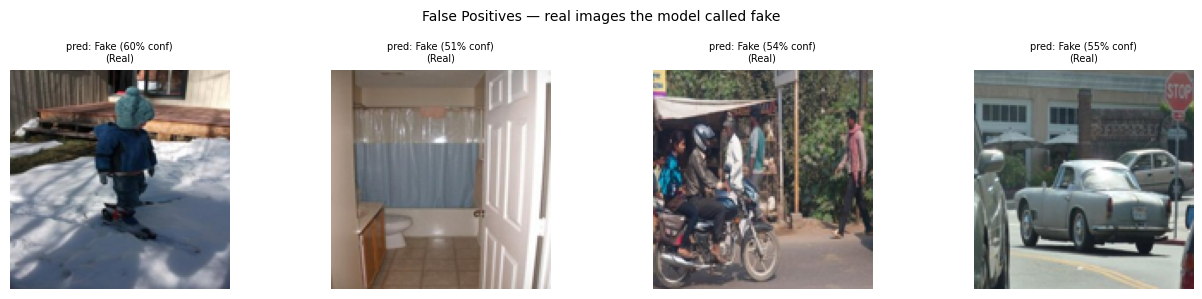

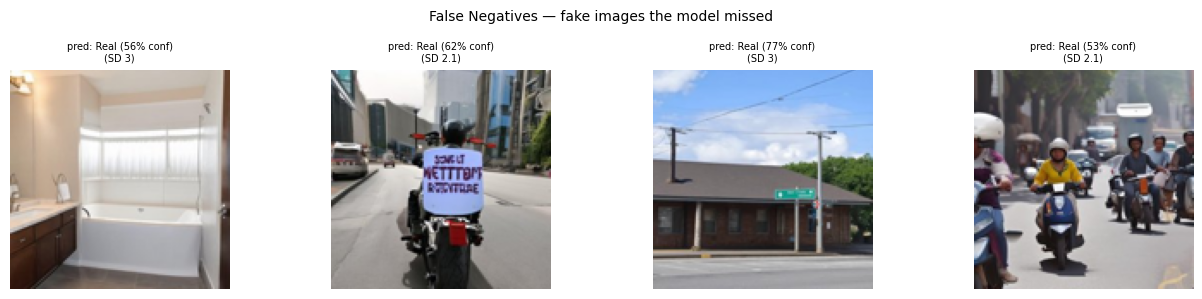

In [ ]:
# Exercise 4.2: Separate False Positives from False Negatives
#
# results_df has one row per test image:
#   true_label   0 = Real,  1 = Fake
#   pred_label   0 = predicted Real, 1 = predicted Fake
#   confidence   probability the model assigned to Fake
#   generator    source (Real, SD 2.1, SDXL, …)
#   img_idx      index into X_test
#
# A false positive  = model cried "fake" but the image was real  (true=0, pred=1)
# A false negative  = model missed a fake and called it real     (true=1, pred=0)
#
# Fill in the four label values below:

false_positives = results_df[
    (results_df["true_label"] == 0) &
    (results_df["pred_label"] == 1)
]

false_negatives = results_df[
    (results_df["true_label"] == 1) &
    (results_df["pred_label"] == 0)
]

print(f"False positives (real images flagged as fake): {len(false_positives)}")
print(f"False negatives (fakes that slipped through) : {len(false_negatives)}")

show_error_type(false_positives, "False Positives — real images the model called fake", n=4)
show_error_type(false_negatives, "False Negatives — fake images the model missed",     n=4)


In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Patterns in mistakes
#@markdown *Are the misclassified images random, or do they share something in common — subject matter, composition, color palette, or level of detail? Can you describe what a "hard" image for this model looks like?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## 4.4. Why Are These Errors Happening?

Saliency maps show *where* the model was "looking" when it made its prediction.
Each pixel's brightness in the heatmap reflects how much that pixel influenced the output.
Bright regions = the model cared a lot about that area.

This helps us answer: is the model using sensible cues (artifact-heavy textures),
or has it latched onto something spurious (a watermark, a background gradient, the image border)?

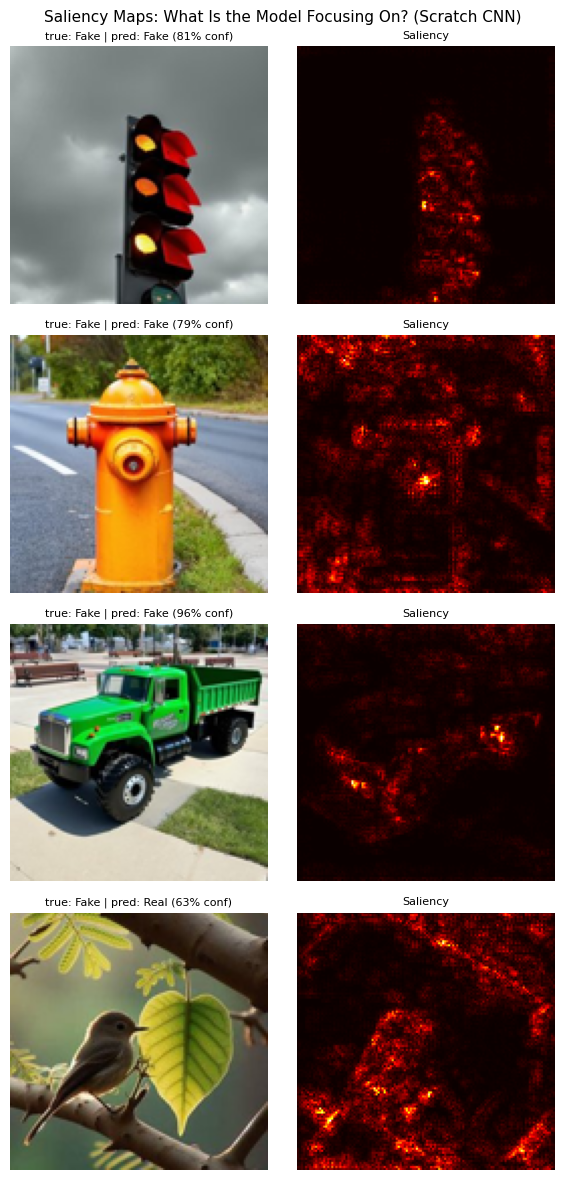

In [ ]:
#@title 🗺 Saliency maps {"display-mode":"form"}
show_saliency(model, results_df, model_name="Scratch CNN")

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ What is the model focusing on?
#@markdown *Are the bright regions in the saliency maps concentrated on the main subject (a face, an object), or on background textures, edges, and fine detail? What would each pattern imply about what the model has actually learned?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Spurious correlations
#@markdown *If the saliency map consistently highlights the image border or a uniform background region rather than any distinctive artifact, what might that suggest about a bias in the training data? How could you test whether the model is using a spurious cue?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

---
---
# **🔀 Milestone 5: Transfer Learning**

Training a CNN from scratch means the model has to learn everything from our dataset alone: edges, textures, shapes, and the subtle artifacts that distinguish fake from real. That is a lot to ask, especially with a limited number of images.

**Transfer learning** takes a different approach: start with a network that was already trained on a massive dataset (ImageNet, roughly 14 million images), and adapt it to our task. The pretrained network already knows how to see. We just need to teach its final layers to use those features for our specific classification problem.

## 5.1. How It Works

We take a pretrained backbone (like MobileNetV2 or ResNet50), **freeze most of its layers** to preserve what it already learned, and **fine-tune only the last few layers** plus a new classification head on our data.

```
Pretrained backbone (frozen layers   preserve ImageNet features)
    |
Last 20 layers (fine-tuned           adapt to our domain)
    |
GlobalAveragePooling2D
    |
Dense(128, relu) + Dropout(0.5)
    |
Dense(1, sigmoid)                    P(fake)
```

This typically trains faster and achieves higher accuracy than a scratch model, especially when the dataset is relatively small.

In [ ]:
#@title 🏗 Transfer model builder {"display-mode":"form"}
import keras

def build_transfer_model(backbone_name):
  backbones = {
    "resnet50":     keras.applications.ResNet50,
    "mobilenet":    keras.applications.MobileNetV2,
    "efficientnet": keras.applications.EfficientNetB0,
    "xception":     keras.applications.Xception,
    "densenet":     keras.applications.DenseNet121,
  }
  rescaling = {
    "resnet50":     keras.layers.Rescaling(scale=255.),
    "mobilenet":    keras.layers.Rescaling(scale=2., offset=-1),
    "efficientnet": keras.layers.Rescaling(scale=1.),
    "xception":     keras.layers.Rescaling(scale=2., offset=-1),
    "densenet":     keras.layers.Rescaling(scale=1./255.),
  }
  assert backbone_name in backbones, f"Choose from {list(backbones.keys())}"

  base = backbones[backbone_name](
    include_top=False, weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
  )
  for layer in base.layers[:-20]:
    layer.trainable = False
  for layer in base.layers[-20:]:
    layer.trainable = True

  inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
  x       = rescaling[backbone_name](inputs)
  x       = base(x, training=False)
  x       = keras.layers.GlobalAveragePooling2D()(x)
  x       = keras.layers.Dense(128, activation="relu")(x)
  x       = keras.layers.Dropout(0.5)(x)
  outputs = keras.layers.Dense(1, activation="sigmoid")(x)

  m = keras.Model(inputs, outputs)
  return m

## 5.2. Choose a Backbone

Try one of the available backbones. Each has different trade-offs:

| Backbone | Parameters | Speed | Notes |
|---|---|---|---|
| `mobilenet` | ~3.4M | Fast | Designed for efficiency; good starting point |
| `resnet50` | ~25M | Medium | Classic deep residual network; strong features |
| `efficientnet` | ~5.3M | Fast | Strong accuracy/efficiency ratio |
| `xception` | ~22M | Slower | Depthwise separable convolutions; often very strong |
| `densenet` | ~8M | Medium | Dense connections between layers |

Change the `backbone_name` below and re-run to try different ones.

In [ ]:
# Exercise 5.2: Set Up and Train Your Transfer Model
#
# Same structure as 3.2 — fill in the same dataset blanks, plus choose a backbone.
# Key difference: use a LOWER learning rate so we don't overwrite the
# pretrained ImageNet features.

# ── Settings ───────────────────────────────────────────────────────────────
backbone_name          = "xception"  # choose from the table above
transfer_learning_rate = 0.001         # lower than CNN — gentle fine-tuning
transfer_max_epochs    = 20
transfer_patience      = 5

# ── Build ──────────────────────────────────────────────────────────────────
import gc, keras as _keras
try:
    del transfer_model, history_transfer # Remove any previous models if they exist to save on memory
except NameError:
    pass
gc.collect()
_keras.backend.clear_session()

transfer_model = build_transfer_model(backbone_name)
print(f"Built {backbone_name}  ({transfer_model.count_params():,} params)")

# ── Compile ────────────────────────────────────────────────────────────────
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=transfer_learning_rate),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ── Train ──────────────────────────────────────────────────────────────────
history_transfer = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=batch_size,
    shuffle=True,
    epochs=transfer_max_epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=transfer_patience,
            restore_best_weights=True
        )
    ]
)

Built xception  (21,123,881 params)
Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 103ms/step - accuracy: 0.8065 - loss: 0.4259 - val_accuracy: 0.8436 - val_loss: 0.4192
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9012 - loss: 0.2334 - val_accuracy: 0.8543 - val_loss: 0.3901
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9487 - loss: 0.1292 - val_accuracy: 0.8636 - val_loss: 0.6034
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9691 - loss: 0.0810 - val_accuracy: 0.8411 - val_loss: 0.7343
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.9774 - loss: 0.0624 - val_accuracy: 0.8671 - val_loss: 0.7277
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.9862 - loss: 0.0411 - val_accuracy: 0.8764 - val_loss: 0.7963
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.8961 - val_loss: 0.7077


Once your transfer model has finished training, run the cell below to see the training history and a comparison of results with the earlier CNN!

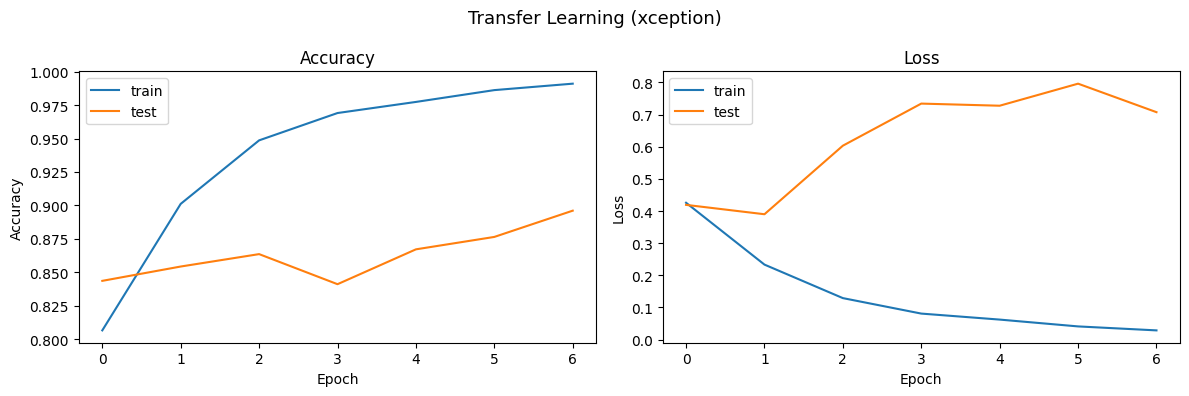

Transfer learning (xception) test accuracy: 0.854
Scratch CNN test accuracy: 0.820


In [ ]:
plot_history(history_transfer, f"Transfer Learning ({backbone_name})")

results_transfer = get_predictions(transfer_model)
transfer_acc     = (results_transfer['true_label'] == results_transfer['pred_label']).mean()
print(f"Transfer learning ({backbone_name}) test accuracy: {transfer_acc:.3f}")
print(f"Scratch CNN test accuracy: {overall_acc:.3f}")

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Did transfer learning help?
#@markdown *Did the transfer model beat the scratch CNN? By roughly how many percentage points?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Training curves comparison
#@markdown *Look at both sets of training curves. Did the transfer model converge in fewer epochs, reach a higher final accuracy, or both? What does that tell you about starting from pretrained weights vs. random weights?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Why does ImageNet pretraining help?
#@markdown *Transfer models were trained on natural photographs of everyday objects, not deepfakes. Why might features learned from those images still be useful for spotting AI-generated images?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## 5.3. Error Analysis: Transfer Model

Let's run the same three-stage analysis on the transfer model and compare it with what you saw for the scratch CNN.

In [ ]:
#@title 📊 Transfer model — confusion matrix & per-generator accuracy {"display-mode":"form"}
import seaborn as sns

_results = results_transfer
_acc     = (_results["true_label"] == _results["pred_label"]).mean()

# Per-generator accuracy
gen_acc_t = _results.groupby("generator").apply(
    lambda x: (x["true_label"] == x["pred_label"]).mean(), include_groups=False
).reset_index()
gen_acc_t.columns = ["generator", "accuracy"]
gen_acc_t = gen_acc_t.sort_values("accuracy")

colors = ["#70AD47" if g == "Real" else
          ("salmon" if a < 0.6 else "#5B9BD5")
          for g, a in zip(gen_acc_t["generator"], gen_acc_t["accuracy"])]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].barh(gen_acc_t["generator"], gen_acc_t["accuracy"], color=colors)
axes[0].axvline(0.5,  color="red",   linestyle="--", alpha=0.7, label="Chance (50%)")
axes[0].axvline(_acc, color="green", linestyle="--", alpha=0.7,
                label=f"Overall ({_acc:.2f})")
axes[0].axvline(overall_acc, color="gray", linestyle=":", alpha=0.7,
                label=f"Scratch CNN ({overall_acc:.2f})")
axes[0].set_title("Accuracy by Source — Transfer Model")
axes[0].set_xlabel("Accuracy"); axes[0].set_xlim(0, 1); axes[0].legend()

fp = len(_results[(_results["true_label"] == 0) & (_results["pred_label"] == 1)])
fn = len(_results[(_results["true_label"] == 1) & (_results["pred_label"] == 0)])
tp = len(_results[(_results["true_label"] == 1) & (_results["pred_label"] == 1)])
tn = len(_results[(_results["true_label"] == 0) & (_results["pred_label"] == 0)])

cm = [[tn, fp], [fn, tp]]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Real", "Predicted Fake"],
            yticklabels=["Actually Real",  "Actually Fake"], ax=axes[1])
axes[1].set_title("Confusion Matrix — Transfer Model")

axes[2].bar(["False Positives\n(real → fake)", "False Negatives\n(fake → real)"],
            [fp, fn], color=["steelblue", "salmon"])
axes[2].set_title("FP vs FN — Transfer Model")
axes[2].set_ylabel("Count")

plt.suptitle(f"Transfer Model Error Analysis  |  test acc: {_acc:.3f}", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Transfer model:  acc={_acc:.3f}  FP={fp}  FN={fn}")
print(f"Scratch CNN:     acc={overall_acc:.3f}  (compare per-generator bars)")


NameError: name 'results_transfer' is not defined

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Generator comparison — transfer vs. scratch
#@markdown *Which generator improved the most between the scratch CNN and the transfer model? Which one is still being missed most often? Why might pretraining help more for some generators than others?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Did the error balance shift?
#@markdown *Compared to the scratch CNN, did the transfer model make more false positives (real images flagged as fake) or more false negatives (fakes that slipped through)?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## 5.4. What Do the Transfer Model's Mistakes Look Like?

In [ ]:
show_misclassified(results_transfer, model_name=f"Transfer ({backbone_name})")

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Same mistakes or different?
#@markdown *Compare the transfer model's misclassified images to what you saw for the scratch CNN. Are they making the same kinds of errors, or does the transfer model fail on different images? What does that suggest about what each model has learned?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## 5.5. What Is the Transfer Model Looking At?

In [ ]:
#@title 🗺 Saliency maps — Transfer Model {"display-mode":"form"}
show_saliency(transfer_model, results_transfer, model_name=f"Transfer ({backbone_name})")

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ Where does the transfer model look?
#@markdown *Do the transfer model's saliency maps highlight different regions than the scratch CNN's? Describe what you see — are they focused on the face, background, edges, or something else?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ What does focus tell us?
#@markdown *A tightly focused saliency map means the model is basing its decision on a small, specific region. Is that a good sign or a warning sign? When might it be both?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

## (Optional) Validation Set vs. Test Set


In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ (Optional) How biased is our accuracy estimate?
#@markdown *We used the test set both to guide EarlyStopping during training and to report final accuracy. Does that make our reported number too optimistic, too pessimistic, or unaffected? Why?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

In [ ]:
#@title {"display-mode":"form", "form-width":"25%"}
#@markdown ### ✏️ (Optional) How would you fix it?
#@markdown *What would you need to do to get a truly unbiased accuracy estimate? Is it practical to do that here, given our dataset size?*

response = "" #@param {type:"string"}
handle_discussion_response(response)

# 🎁 **Wrapping Up**

---
>  You've built and compared two approaches to deepfake detection: a scratch CNN, and a transfer-learned backbone. You've seen how accuracy varies by generator, what kinds of errors each model makes, and what the gap between false positives and false negatives means in practice.
>
> The best model you built probably sits somewhere in the 75-90% accuracy range. That is meaningful, but it also means 10-25% of images get the wrong label. And a model trained on these four generators may struggle with a new or updated generator it has never seen.
>
> In **NB3**, you'll zoom out from the models themselves and think about the larger system: what role does detection play, what other tools exist (content provenance, watermarking, platform policies), and what it actually means to preserve trust in media at a moment when the technology to undermine it is advancing quickly.

---
---
## 📦 Export Your Project Files

Run the cell below to package your trained model and download it to your computer.

You'll upload this file in the **[Model Deployment Notebook](https://inspiritai.co/model_app_deployment)** to build and deploy your app.

In [ ]:
#@title Run to export your project files 📥 { display-mode: "form" }
import os, shutil, json as _json
from google.colab import files

os.makedirs('hf_export', exist_ok=True)
os.makedirs('hf_export/sample_images', exist_ok=True)

# Save the trained model.
# By default this exports the transfer model.
# Replace `transfer_model` with `model` to deploy the scratch CNN model instead.
transfer_model.save('hf_export/deepfake_detector.keras')
print('Model saved')

# Class names in model output order  (0 = Real, 1 = AI-Generated)
class_names = ['Real', 'AI-Generated']
with open('hf_export/class_names.json', 'w') as f:
    _json.dump(class_names, f)
print('class_names.json saved')

# Save a few sample images from the test set for the app's click-to-try examples
for label_idx, label_name in enumerate(class_names):
    sample_indices = np.where(y_test == label_idx)[0][:5]
    for j, idx in enumerate(sample_indices):
        arr = (X_test[idx] * 255).clip(0, 255).astype('uint8')
        Image.fromarray(arr).save(
            f"hf_export/sample_images/{label_name.replace(' ', '_')}_{j}.png"
        )
print('Sample images saved')

# Save helpers.py - exact preprocessing + correct single-sigmoid -> label mapping,
# so the app cannot break the detector with the wrong input scale or an argmax.
helpers_code = """# TruthLens deepfake detector - preprocessing + inference helper.
# The model expects 128x128 RGB images normalized to 0-1 (divide by 255).
# It outputs ONE sigmoid value = P(AI-Generated). class_names = ["Real", "AI-Generated"].
# Label is "AI-Generated" if prob >= 0.5 else "Real". Do NOT argmax a single-value output.
import numpy as np
from PIL import Image

IMG_SIZE = 128

def preprocess(image):
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype("uint8"))
    image = image.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(image).astype("float32") / 255.0
    return np.expand_dims(arr, 0)

def predict(model, image, class_names=("Real", "AI-Generated")):
    prob_ai = float(model.predict(preprocess(image), verbose=0).flatten()[0])
    scores = {class_names[0]: 1.0 - prob_ai, class_names[1]: prob_ai}
    label = class_names[1] if prob_ai >= 0.5 else class_names[0]
    return label, scores
"""
with open('hf_export/helpers.py', 'w') as f:
    f.write(helpers_code)
print('helpers.py saved')

# Requirements for the deployed app
with open('hf_export/requirements.txt', 'w') as f:
    f.write('gradio\ntensorflow\nnumpy\nPillow\n')
print('requirements.txt saved')

# Zip and download
shutil.make_archive('project_export', 'zip', 'hf_export')
files.download('project_export.zip')
print('\nproject_export.zip downloaded!')

Model saved
class_names.json saved
Sample images saved
helpers.py saved
requirements.txt saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


project_export.zip downloaded!




Congratulations, that's the end of this notebook!

Beyond this notebook, your group has a choice on what you'd like to cover next:
- open the **[Model Deployment Notebook](https://inspiritai.co/model_app_deployment)** to turn your model into a live web app anyone can use.
- OR move on to **Notebook 3** to discuss strategies beyond detection in combatting deepfakes. You can go to model deployment at any point in Notebook 3 now that your models are downloaded; many of the lessons learned in Notebook 3 can even be incorporated into your app to make it more educational!